In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt


## (a) Algorithm implementation

In [2]:
class KeyComparisons:
    def __init__(self):
        self.numofkeycomp = 0

    def lessthanb(self, a, b) -> bool:
        self.numofkeycomp += 1
        return a < b

    def resetnum(self):
        self.numofkeycomp = 0

    def returnkeycomp(self):
        return self.numofkeycomp

def merge(arr, left, mid, right, myObj):
    n1 = mid - left + 1
    n2 = right - mid
    L = [0] * n1
    R = [0] * n2

    for i in range(n1):
        L[i] = arr[left + i]
    for j in range(n2):
        R[j] = arr[mid + 1 + j]

    i, j, k = 0, 0, left
    while i < n1 and j < n2:
        if myObj.lessthanb(R[j], L[i]):
            arr[k] = R[j]
            j += 1
        else:
            arr[k] = L[i]
            i += 1
        k += 1
    while i < n1:
        arr[k] = L[i]
        i += 1
        k += 1
    while j < n2:
        arr[k] = R[j]
        j += 1
        k += 1
    return arr

def mergesort(arr, left, right, myObj):
    if left < right:
        mid = (left + right) // 2
        mergesort(arr, left, mid, myObj)
        mergesort(arr, mid + 1, right, myObj)
        merge(arr, left, mid, right, myObj)
    return arr

def insertion(arr, left, right, myObj):
    for i in range(left + 1, right + 1):
        key = arr[i]
        j = i - 1
        while j >= left and myObj.lessthanb(key, arr[j]):
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

# If the subarray is small enough (<= S), sort it directly with insertion sort, otherwise, split, recursively hybrid-sort both halves, then merge.

def hybridSort(arr, left, right, S, myObj):
    if right - left + 1 <= S:
        return insertion(arr, left, right, myObj)
    mid = (left + right) // 2
    hybridSort(arr, left, mid, S, myObj)
    hybridSort(arr, mid + 1, right, S, myObj)
    merge(arr, left, mid, right, myObj)
    return arr


## (b) Generate input data

In [3]:
def generate_data(n, seed):
    rng = np.random.default_rng(seed)
    return list(rng.integers(1, n + 1, size=n))

SIZES = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000,
         500000, 1000000, 2000000, 5000000, 10000000]


### Correctness checks for sorts implementations

In [4]:
cases = []
cases.append([])
cases.append([5])
cases.append([2, 1])

duplicate_list = []
for i in range(50):
    duplicate_list.append(7)
cases.append(duplicate_list)

sorted_list = []
for i in range(100):
    sorted_list.append(i)
cases.append(sorted_list)

reverse_list = []
for i in range(100, 0, -1):
    reverse_list.append(i)
cases.append(reverse_list)

cases.append(generate_data(5000, seed=1))

S_values_to_test = [1, 5, 20, 100, 10000]

for data in cases:
    arr = list(data)
    mergesort(arr, 0, len(arr) - 1, KeyComparisons())
    assert arr == sorted(data), "mergesort gave wrong result"

    for S in S_values_to_test:
        arr = list(data)
        hybridSort(arr, 0, len(arr) - 1, S, KeyComparisons())
        assert arr == sorted(data), "hybridSort gave wrong result"

print("mergesort and hybridSort give correct results.")


mergesort and hybridSort give correct results.


## (c) Analyze time complexity
`run()` times a sort and counts key comparisons; `theoretical_comparisons()` computes the 
expected comparison count via the hybrid sort's recurrence relation.

In [5]:
def run(data, S=None, repeats=1):
    copies = []
    for i in range(repeats):
        copies.append(list(data))

    start = time.process_time()
    for arr in copies:
        myObj = KeyComparisons()
        if S is None:
            mergesort(arr, 0, len(arr) - 1, myObj)
        else:
            hybridSort(arr, 0, len(arr) - 1, S, myObj)
        comparisons = myObj.returnkeycomp()
    end = time.process_time()

    total_time = end - start
    cpu_time = total_time / repeats
    return comparisons, cpu_time

def theoretical_comparisons(n, S):
    def helper(size):
        if size <= S:
            return 0, size * (size - 1) / 4   #average case = 1/2 * n(n-1)/2 = n*(n-1)/4 for insertion sort
        left = size // 2
        right = size - left
        left_merge, left_ins = helper(left)
        right_merge, right_ins = helper(right)
        return left_merge + right_merge + size, left_ins + right_ins
    merge_total, insertion_total = helper(n)
    return merge_total + insertion_total      #average case for merge sort + insertion sort (hybrid sort) = nlog(n/S) + n*S/4


Why average case of hybrid sort is nlog(n/S) + n*S/4?

**Merge sort = nlog(n/S)**

n = comparisons per merge pass

log(n/S) = number of passes (halvings until reaching size S)

n * log(n/S) = nlog(n/S)
****

**Insertion sort = n*S/4**

n/S = number of arrays with size = S

S²/4 = comparisons per array

n/S * S^2/4 = nS/4

****
Best Case: O(n) + O(n log (n/S)) = O(n + n log(n/S))  
Worst Case: O(nS) + O(n log (n/S)) = O(nS + n log(n/S)) 


### (c)(i) Key comparisons vs n

n = 1000: comparisons = 9182, theory = 8708, empirical / theory = 1.054
n = 2000: comparisons = 20232, theory = 19416, empirical / theory = 1.042
n = 5000: comparisons = 58607, theory = 55980, empirical / theory = 1.047
n = 10000: comparisons = 126902, theory = 121960, empirical / theory = 1.041
n = 20000: comparisons = 273663, theory = 263920, empirical / theory = 1.037
n = 50000: comparisons = 729243, theory = 713984, empirical / theory = 1.021
n = 100000: comparisons = 1558165, theory = 1527968, empirical / theory = 1.020
n = 200000: comparisons = 3316632, theory = 3255936, empirical / theory = 1.019
n = 500000: comparisons = 9037666, theory = 8832496, empirical / theory = 1.023
n = 1000000: comparisons = 19071374, theory = 18664992, empirical / theory = 1.022
n = 2000000: comparisons = 40146445, theory = 39329984, empirical / theory = 1.021
n = 5000000: comparisons = 108209015, theory = 105703520, empirical / theory = 1.024
n = 10000000: comparisons = 226419043, theory = 221407040,

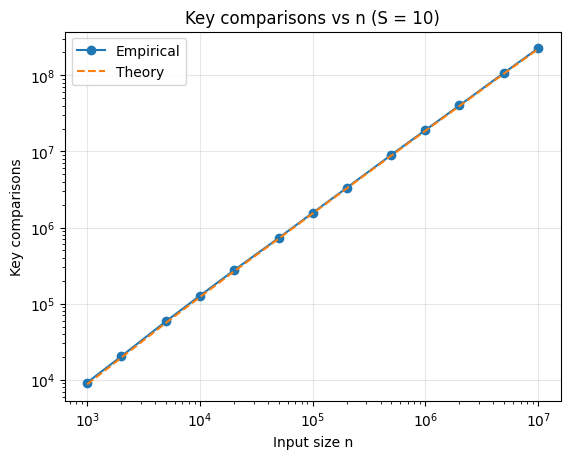

In [6]:
S = 10
comparisons_list = []
theory_list = []

for n in SIZES:
    comparisons = run(generate_data(n, seed=n), S)[0]
    theory = theoretical_comparisons(n, S)
    comparisons_list.append(comparisons)
    theory_list.append(theory)
    print(f"n = {n}: comparisons = {comparisons}, theory = {theory:.0f}, "
          f"empirical / theory = {comparisons / theory:.3f}")

plt.plot(SIZES, comparisons_list, "o-", label="Empirical")
plt.plot(SIZES, theory_list, "--", label="Theory")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input size n")
plt.ylabel("Key comparisons")
plt.title(f"Key comparisons vs n (S = {S})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Empirical comparisons closely track the theoretical prediction (within ~2–5%), and both grow roughly as O(n log n), confirming the hybrid sort behaves as expected across input sizes at a fixed S = 10.

### (c)(ii) Key comparisons vs S

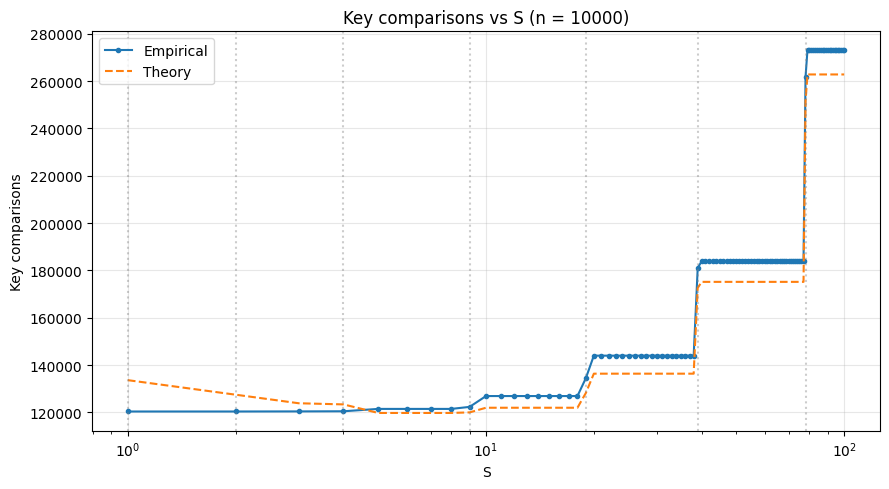

In [7]:
n = 10000
data = generate_data(n, seed=n)
S_values = list(range(1, 101))
comparisons_list = []
theory_list = []

for S in S_values:
    comparisons = run(data, S)[0]
    comparisons_list.append(comparisons)
    theory_list.append(theoretical_comparisons(n, S))

# find the recursion's actual leaf sizes, to mark where jumps happen
leaf_sizes = []
current_size = n
while current_size > 1:
    if current_size not in leaf_sizes:
        leaf_sizes.append(current_size)
    current_size = current_size // 2
if 1 not in leaf_sizes:
    leaf_sizes.append(1)

boundaries = []
for size in leaf_sizes:
    if size >= 1 and size <= 100:
        boundaries.append(size)
boundaries.sort()

plt.figure(figsize=(9, 5))
plt.plot(S_values, comparisons_list, "o-", markersize=3, label="Empirical")
plt.plot(S_values, theory_list, "--", label="Theory")
for b in boundaries:
    plt.axvline(b, color="gray", linestyle=":", alpha=0.4)
plt.xscale("log")
plt.xlabel("S")
plt.ylabel("Key comparisons")
plt.title(f"Key comparisons vs S (n = {n})")
plt.legend()
plt.grid(alpha=0.3)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


Merge Sort halving process =  10000, 5000, 2500, 1250, 625, 312, 156, 78, 39, 19, 9, 4, 2, 1

Note that the graph steps only at S = 1, 2, 4, 9, 19, 39, 78.

These are the exact subarray sizes produced by repeatedly halving n=10,000. Comparisons only change when S crosses one of these sizes, since that's when a whole tier of subarrays switches from merge sort to insertion sort at once. Any S between two of these values catches nothing new, so the curve stays flat, hence the step shape instead of a continuous graph.

 Key comparisons increase in a step-wise pattern as S grows, with jumps occurring near the recursion's actual leaf sizes (marked by dotted lines). This happens because larger S means insertion sort handles bigger subarrays, and insertion sort needs more comparisons than merge sort on the same subarray, especially as size grows past a few elements.

### (c)(iii) Optimal S for different n

n = 1000: best S by comparisons = 3, best S by CPU time = 11
n = 10000: best S by comparisons = 1, best S by CPU time = 13
n = 100000: best S by comparisons = 1, best S by CPU time = 8
n = 1000000: best S by comparisons = 3, best S by CPU time = 11


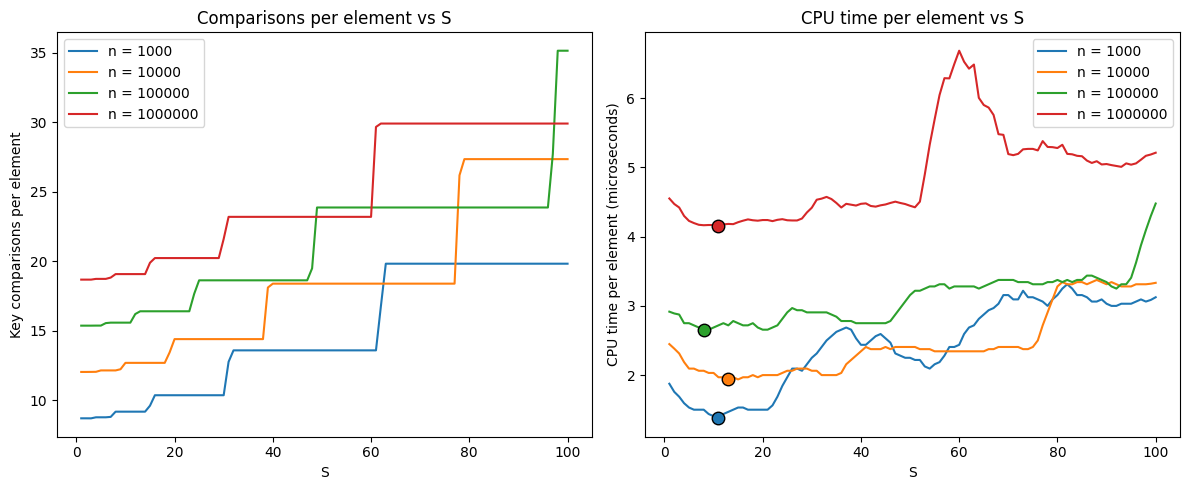

In [10]:
S_values = list(range(1, 101))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for n in [1000, 10000, 100000, 1000000]:
    data = generate_data(n, seed=n)
    repeats = max(1, 100000 // n)

    comparisons_list = []
    time_list = []
    for S in S_values:
        comparisons, cpu_time = run(data, S, repeats)
        comparisons_list.append(comparisons / n)
        time_list.append(cpu_time / n * 1e6)

    # simple smoothing: average each point with its 2 neighbors
    smoothed = []
    for i in range(len(time_list)):
        window = time_list[max(0, i-2):i+3]
        smoothed.append(sum(window) / len(window))

    best_S_comparisons = S_values[comparisons_list.index(min(comparisons_list))]
    best_S_time = S_values[smoothed.index(min(smoothed))]
    print(f"n = {n}: best S by comparisons = {best_S_comparisons}, best S by CPU time = {best_S_time}")

    ax1.plot(S_values, comparisons_list, label=f"n = {n}")

    line, = ax2.plot(S_values, smoothed, label=f"n = {n}")
    ax2.plot(best_S_time, smoothed[best_S_time - 1], "o", color=line.get_color(), markersize=9, markeredgecolor="black")

ax1.set_xlabel("S"); ax1.set_ylabel("Key comparisons per element")
ax1.set_title("Comparisons per element vs S"); ax1.legend()

ax2.set_xlabel("S"); ax2.set_ylabel("CPU time per element (microseconds)")
ax2.set_title("CPU time per element vs S"); ax2.legend()

plt.tight_layout()
plt.show()

Comparisons favor small S (best around S = 1-3), while CPU time favors a larger S, though the exact best value varies with n (11, 13, 8, 11) due to timing noise. Averaging these gives S = 11, which we adopt as our final value since CPU time better reflects real-world performance than raw comparison count.

## (d) Compare with original merge sort

In [12]:
S = 11
n = 10000000
data = generate_data(n, seed=n)

hybrid_comparisons, hybrid_time = run(data, S)
merge_comparisons, merge_time = run(data)

print("Hybrid sort (S =", S, ")")
print("  Comparisons:", hybrid_comparisons)
print("  CPU time (s):", round(hybrid_time, 2))
print()
print("Merge sort")
print("  Comparisons:", merge_comparisons)
print("  CPU time (s):", round(merge_time, 2))
print()

comparisons_ratio = hybrid_comparisons / merge_comparisons
time_ratio = hybrid_time / merge_time
print("Hybrid / merge sort: comparisons =", round(comparisons_ratio, 3),
      ", CPU time =", round(time_ratio, 3))


Hybrid sort (S = 11 )
  Comparisons: 226419043
  CPU time (s): 68.58

Merge sort
  Comparisons: 220103325
  CPU time (s): 73.48

Hybrid / merge sort: comparisons = 1.029 , CPU time = 0.933


At S = 11, the hybrid sort does slightly more comparisons than plain merge sort (ratio ≈ 1.029), because insertion sort at this threshold is no longer as comparison-efficient as merge sort on the same subarray size. However, CPU time is about 6.7% lower (ratio ≈ 0.933), since insertion sort avoids the recursive call and temporary array allocation overhead that merge sort incurs at small subarray sizes. This confirms our choice of S = 11 based on CPU time, as it trades a small increase in comparisons for faster speed.